In [1]:
import pandas as pd

populacao_estados = pd.read_excel('pop.xls', header=1, skipfooter=34)

#populacao_estados['POPULAÇÃO'].astype(int)
#populacao_estados.groupby('UF').sum(numeric_only=True)

#populacao_estados[populacao_estados['POPULAÇÃO'].str.contains('\(', na=False)]

In [2]:
populacao_estados = populacao_estados.assign(
        populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\([0-9]*\)', '', regex=True),
        populacao = lambda x : x.loc[:, 'populacao_sem_parenteses'].replace('\.','', regex=True)
)

populacao_estados = populacao_estados.astype({'populacao': 'int64'})

In [3]:
populacao_estados = populacao_estados.groupby('UF')[['populacao']].sum()

In [5]:
populacao_estados = populacao_estados.reset_index()

In [6]:
emissoes_gases = pd.read_excel('dados.xlsx', sheet_name = 'GEE Estados')

c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [7]:
emissoes_gases_apenas_emissao = emissoes_gases[emissoes_gases['Emissão / Remoção / Bunker'] == 'Emissão'].drop(columns='Emissão / Remoção / Bunker')

colunas_info = list(emissoes_gases_apenas_emissao.loc[:, 'Nível 1 - Setor':'Produto'].columns)

colunas_emissao = list(emissoes_gases_apenas_emissao.loc[:, 1970:2021].columns)

emissoes_por_ano = emissoes_gases_apenas_emissao.melt(id_vars=colunas_info, value_vars=colunas_emissao, var_name="Ano", value_name="Emissao")

gas_por_setor = emissoes_por_ano.groupby(["Gás", "Nível 1 - Setor"])[["Emissao"]].sum()

valores_max = gas_por_setor.groupby(level=0).max().values

tabela_sumarizada = gas_por_setor.groupby(level=0).idxmax()
tabela_sumarizada.insert(1, "Quantidade de Emissao", valores_max)

media_emissao_anual = emissoes_por_ano.groupby(['Ano', 'Gás'])[['Emissao']].mean().reset_index()
media_emissao_anual = media_emissao_anual.pivot_table(index='Ano', columns='Gás', values='Emissao')

In [10]:
emissao_estados = emissoes_por_ano[emissoes_por_ano['Ano'] == 2021].groupby('Estado')[['Emissao']].sum().reset_index()
emissao_estados

,Estado,Emissao
0,AC,3.505471e+08
1,AL,6.261279e+07
2,AM,1.189649e+09
3,AP,3.568410e+07
4,BA,5.932251e+08
5,CE,2.034731e+08
6,DF,5.668738e+07
7,ES,2.697547e+08
8,GO,6.008081e+08
9,MA,9.476324e+08


<Axes: xlabel='populacao', ylabel='Emissao'>

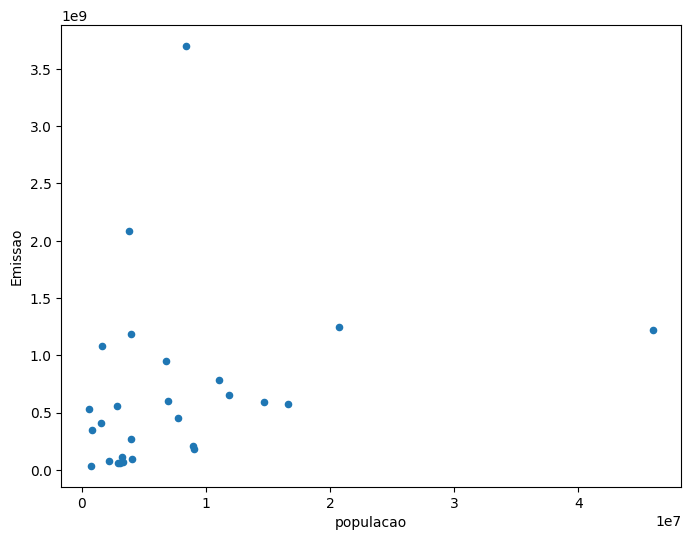

In [16]:
dados_agrupados = pd.merge(emissao_estados, populacao_estados, left_on="Estado", right_on="UF")

dados_agrupados.plot(x="populacao", y="Emissao", kind="scatter", figsize=(8,6))

In [23]:
import plotly.express as px

px.scatter(data_frame=dados_agrupados, x="populacao", y="Emissao", text="Estado", opacity=0)

In [24]:
dados_agrupados = dados_agrupados.assign(
    emissao_per_capita = dados_agrupados["Emissao"] / dados_agrupados["populacao"]
).sort_values("emissao_per_capita", ascending=False)

,Estado,Emissao,index,UF,populacao,emissao_per_capita
21,RR,5.282071e+08,21,RR,634805,832.077694
20,RO,1.083515e+09,20,RO,1616379,670.334662
12,MT,2.081610e+09,12,MT,3784239,550.073647
13,PA,3.701684e+09,13,PA,8442962,438.434230
0,AC,3.505471e+08,0,AC,829780,422.457928
2,AM,1.189649e+09,2,AM,3952262,301.004463
26,TO,4.082159e+08,26,TO,1584306,257.662300
11,MS,5.551278e+08,11,MS,2833742,195.899220
9,MA,9.476324e+08,9,MA,6800605,139.345312
8,GO,6.008081e+08,8,GO,6950976,86.435075


In [26]:
px.bar(data_frame=dados_agrupados, x="Estado", y="emissao_per_capita")

In [28]:
px.scatter(data_frame=dados_agrupados, x="populacao", y="Emissao", text="Estado", size="emissao_per_capita")

ValueError: Value of 'size' is not the name of a column in 'data_frame'. Expected one of ['Estado', 'Emissao', 'index', 'UF', 'populacao', 'emissao_per_capita'] but received: emissao_per_capita * 2